# Pair Traiding 


## Step 1: Universe Selection via Information Theory. 
Do not use linear correlation to find pairs. Instead, use Mutual Information (MI) to detect both linear and non-linear dependence between the fractional differentials of the price series.$$I(X;Y) = \sum_{y \in Y} \sum_{x \in X} p(x,y) \log \left( \frac{p(x,y)}{p(x)p(y)} \right)$$Filter your universe by selecting pairs with the highest mutual information.

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.feature_selection import mutual_info_regression
import warnings
import requests

def get_gaussian_mi_matrix(returns_df: pd.DataFrame) -> pd.DataFrame:
    """
    Computes the Pairwise Mutual Information matrix under a Gaussian assumption.
    Complexity is strictly O(N^2) correlation, avoiding expensive neighbor searches.
    """
    if returns_df.empty:
        raise ValueError("Returns DataFrame is empty.")
        
    # 1. Compute the Pearson correlation matrix (Highly optimized)
    rho_matrix = returns_df.corr(method='pearson')
    
    # 2. Bound the correlation to avoid mathematically undefined log(0) at rho=1 (the diagonal)
    rho_clipped = rho_matrix.clip(lower=-0.99999, upper=0.99999)
    
    # 3. Apply the Gaussian Mutual Information transformation
    mi_matrix = -0.5 * np.log(1 - rho_clipped**2)
    
    # 4. Remove self-information (the diagonal)
    np.fill_diagonal(mi_matrix.values, np.nan)
    
    return mi_matrix

def get_log_returns(tickers, start_date, end_date):
    """
    Fetches adjusted close prices and computes log returns, enforcing stationarity.
    """
    raw = yf.download(
        tickers,
        start=start_date,
        end=end_date,
        auto_adjust=False,
        progress=False,
        threads=True,
    )

    if raw.empty:
        raise ValueError("yfinance returned no data for the requested date range.")

    if isinstance(raw.columns, pd.MultiIndex):
        if 'Adj Close' not in raw.columns.get_level_values(0):
            raise ValueError("'Adj Close' not found in downloaded data.")
        price_data = raw['Adj Close']
    else:
        price_data = raw.rename(columns={'Adj Close': tickers[0] if isinstance(tickers, list) else tickers})
        if 'Adj Close' in price_data.columns:
            price_data = price_data[['Adj Close']]

    if isinstance(price_data, pd.Series):
        ticker_name = tickers[0] if isinstance(tickers, list) else str(tickers)
        price_data = price_data.to_frame(name=ticker_name)

    valid_cols = [col for col in price_data.columns if price_data[col].notna().sum() > 2]
    
    if len(valid_cols) < 2:
        raise ValueError(f"Need at least 2 valid tickers to compute MI. Found: {valid_cols}")

    price_data = price_data[valid_cols]

    # Compute log returns to ensure weak stationarity of the observables
    log_returns = np.log(price_data / price_data.shift(1)).dropna(how='any')

    if log_returns.empty:
        raise ValueError("No overlapping return observations after cleaning.")

    return log_returns

# --- Execution Pipeline ---
#SPY
#tickers = ['NVDA','AAPL','MSFT','AMZN','GOOG','META','AVGO','TSLA','BRK.B','WMT','LLY','JPM','XOM','V','JNJ','MA']

def get_sp500_tickers_by_sector(target_sector: str = "Energy") -> list:
    """
    Scrapes the S&P 500 constituents and filters them by GICS Sector.
    This restricts our state-space to a highly coupled sub-manifold.
    
    Args:
        target_sector: GICS Sector name to filter by, or "All" to get all S&P 500 tickers
    
    Returns:
        List of tickers in the specified sector(s)
    """
    url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
    
    # Required header to bypass CDN bot-protection
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"
    }
    
    response = requests.get(url, headers=headers)
    if response.status_code != 200:
        raise ConnectionError(f"HTTP Error: {response.status_code}")
        
    # Read the first table into a DataFrame
    df = pd.read_html(response.text)[0]
    
    # If "All" is requested, return all tickers without filtering
    if target_sector.lower() == "all":
        tickers = df['Symbol'].str.replace('.', '-', regex=False).tolist()
        return tickers
    
    # Check available sectors to prevent silent failures
    available_sectors = df['GICS Sector'].unique()
    if target_sector not in available_sectors:
        raise ValueError(f"Sector '{target_sector}' not found. Valid sectors are: {available_sectors}")
    
    # Apply the topological constraint (boolean filtering)
    sector_df = df[df['GICS Sector'] == target_sector]
    
    # Format tickers for yfinance compatibility
    tickers = sector_df['Symbol'].str.replace('.', '-', regex=False).tolist()
    
    return tickers

# Create your large ticker vector
tickers_sp500 = get_sp500_tickers_by_sector("All")

# Note: Changed 'BRK.' to 'BRK.B' as yfinance requires the exact ticker
returns_df = get_log_returns(tickers_sp500, '2020-01-01', '2026-01-03')

print("Calculating Gaussian MI Matrix...")
mi_matrix_fast = get_gaussian_mi_matrix(returns_df)

# --- Extract the Top 10 Pairs ---
pairs = []
for i in range(len(mi_matrix_fast.columns)):
    for j in range(i + 1, len(mi_matrix_fast.columns)):
        val = mi_matrix_fast.iloc[i, j]
        if not np.isnan(val):
            pairs.append((mi_matrix_fast.index[i], mi_matrix_fast.columns[j], val))

# Sort descending by Mutual Information
top_10_fast_pairs = sorted(pairs, key=lambda x: x[2], reverse=True)[:10]

print("\nTop 10 Pairs by Gaussian Mutual Information (Ready for KSG validation):")
for rank, (t1, t2, mi_val) in enumerate(top_10_fast_pairs, 1):
    print(f"{rank}. {t1} - {t2} : {mi_val:.4f} nats")

C:\Users\migue\AppData\Local\Temp\ipykernel_7272\3914015320.py:102: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_html(response.text)[0]


Calculating Gaussian MI Matrix...

Top 10 Pairs by Gaussian Mutual Information (Ready for KSG validation):
1. GOOG - GOOGL : 3.0571 nats
2. FOX - FOXA : 1.4646 nats
3. NSC - UNP : 1.0901 nats
4. CFG - USB : 1.0238 nats
5. KLAC - LRCX : 0.9860 nats
6. EQT - EXE : 0.9432 nats
7. ESS - UDR : 0.9078 nats
8. CPT - MAA : 0.8964 nats
9. NWS - NWSA : 0.8781 nats
10. CFG - TFC : 0.8639 nats


In [53]:
top_pairs = sorted(pairs, key=lambda x: x[2], reverse=True)[:20]

# 1. Extract unique tickers from the top 10 Gaussian pairs
surviving_nodes = set()
for t1, t2, mi_val in top_pairs:
    surviving_nodes.add(t1)
    surviving_nodes.add(t2)

# Convert the mathematical set back to a Python list for the API
ksg_ticker_list = list(surviving_nodes)
#Remove all the pairs that are not in the original list of S&P 500 tickers
ksg_ticker_list.remove('GOOGL')
ksg_ticker_list.remove('FOXA')
ksg_ticker_list.remove('NWSA')


print(f"Original Sector Size: {len(tickers_sp500)} stocks")
print(f"Reduced Sub-Manifold Size: {len(ksg_ticker_list)} stocks")
print(f"Tickers to process with KSG: {ksg_ticker_list}\n")

Original Sector Size: 503 stocks
Reduced Sub-Manifold Size: 26 stocks
Tickers to process with KSG: ['TFC', 'EXE', 'LRCX', 'EQT', 'FITB', 'UAL', 'MAA', 'KLAC', 'ESS', 'RF', 'HBAN', 'FOX', 'USB', 'MTB', 'GOOG', 'DAL', 'NWS', 'UDR', 'LEN', 'DHI', 'CFG', 'EQR', 'PHM', 'UNP', 'NSC', 'CPT']



Calculating KSG Mutual Information matrix for 26 assets...


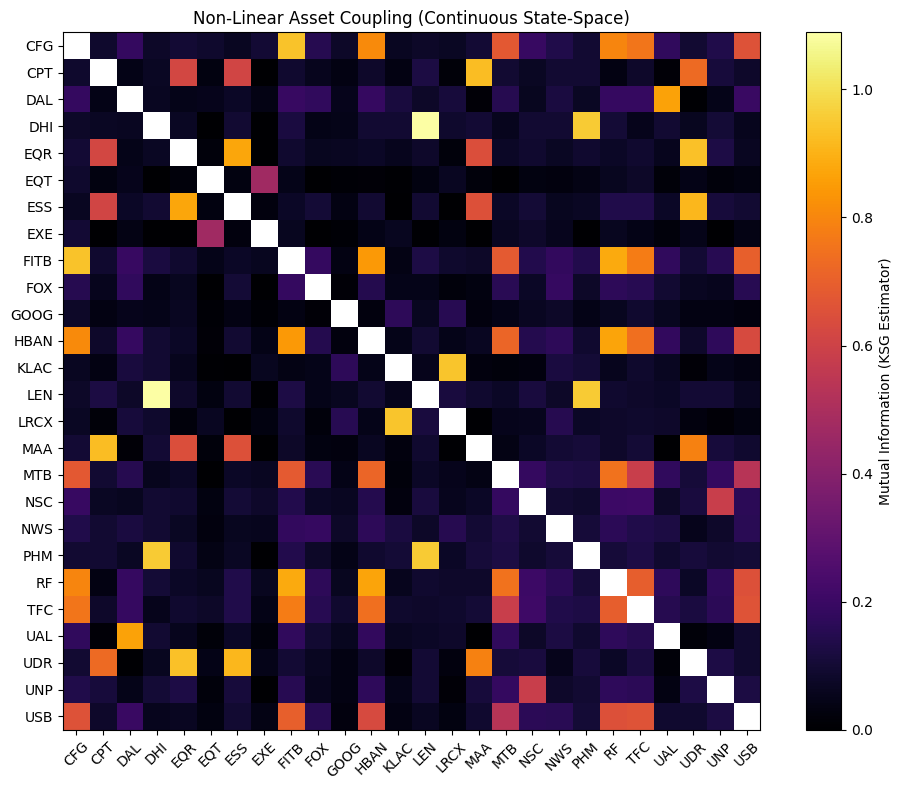

Top 20 Most Coupled Pairs (KSG Continuous Mutual Information):
1. DHI - LEN: 1.0890
2. LEN - PHM: 0.9569
3. DHI - PHM: 0.9534
4. KLAC - LRCX: 0.9408
5. CFG - FITB: 0.9398
6. EQR - UDR: 0.9344
7. CPT - MAA: 0.9240
8. ESS - UDR: 0.9135
9. FITB - RF: 0.8824
10. EQR - ESS: 0.8752
11. HBAN - RF: 0.8680
12. DAL - UAL: 0.8646
13. FITB - HBAN: 0.8452
14. CFG - HBAN: 0.8122
15. CFG - RF: 0.7980
16. MAA - UDR: 0.7912
17. FITB - TFC: 0.7752
18. CFG - TFC: 0.7576
19. MTB - RF: 0.7503
20. HBAN - TFC: 0.7414


In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.feature_selection import mutual_info_regression
import warnings
import requests

def calculate_mi_matrix_ksg(returns_df: pd.DataFrame, k_neighbors: int = 3) -> pd.DataFrame:
    """
    Computes the pairwise Mutual Information matrix using the Kraskov-Stögbauer-Grassberger (KSG)
    k-Nearest Neighbors estimator. Treats the returns as continuous observables in a complex 
    adaptive system, avoiding the discretization bias of histograms.
    """
    if returns_df is None or returns_df.empty:
        raise ValueError("returns_df is empty. No data available to compute MI.")

    clean_returns = returns_df.dropna(how='any')
    if clean_returns.empty:
        raise ValueError("No overlapping return history after NaN cleaning.")

    assets = clean_returns.columns
    data = clean_returns.values
    n_assets = len(assets)

    mi_matrix = np.full((n_assets, n_assets), np.nan)
    
    # Suppress warnings regarding exact zero-variance ties in finite samples
    warnings.filterwarnings("ignore", category=UserWarning)

    print(f"Calculating KSG Mutual Information matrix for {n_assets} assets...")
    
    for i in range(n_assets):
        for j in range(i + 1, n_assets):
            x = data[:, i]
            y = data[:, j]

            # Guard against degenerate (zero-variance) series
            if np.std(x) == 0 or np.std(y) == 0:
                continue
            
            # Reshape X for sklearn's expected feature matrix format
            X = x.reshape(-1, 1)
            Y = y.reshape(-1, 1)
            
            # KSG estimation. We use a fixed random_state because the algorithm 
            # adds a microscopic jitter (~1e-10) to break exact duplicate ties.
            mi_xy = mutual_info_regression(X, y, n_neighbors=k_neighbors, random_state=42)[0]
            
            # KSG is theoretically symmetric, but finite-sample k-NN searches can 
            # induce microscopic asymmetries. We enforce strict physical symmetry.
            mi_yx = mutual_info_regression(Y, x, n_neighbors=k_neighbors, random_state=42)[0]
            mi_symmetric = (mi_xy + mi_yx) / 2.0
            
            mi_matrix[i, j] = mi_symmetric
            mi_matrix[j, i] = mi_symmetric

    return pd.DataFrame(mi_matrix, index=assets, columns=assets)

def get_log_returns(tickers, start_date, end_date):
    """
    Fetches adjusted close prices and computes log returns, enforcing stationarity.
    """
    raw = yf.download(
        tickers,
        start=start_date,
        end=end_date,
        auto_adjust=False,
        progress=False,
        threads=True,
    )

    if raw.empty:
        raise ValueError("yfinance returned no data for the requested date range.")

    if isinstance(raw.columns, pd.MultiIndex):
        if 'Adj Close' not in raw.columns.get_level_values(0):
            raise ValueError("'Adj Close' not found in downloaded data.")
        price_data = raw['Adj Close']
    else:
        price_data = raw.rename(columns={'Adj Close': tickers[0] if isinstance(tickers, list) else tickers})
        if 'Adj Close' in price_data.columns:
            price_data = price_data[['Adj Close']]

    if isinstance(price_data, pd.Series):
        ticker_name = tickers[0] if isinstance(tickers, list) else str(tickers)
        price_data = price_data.to_frame(name=ticker_name)

    valid_cols = [col for col in price_data.columns if price_data[col].notna().sum() > 2]
    
    if len(valid_cols) < 2:
        raise ValueError(f"Need at least 2 valid tickers to compute MI. Found: {valid_cols}")

    price_data = price_data[valid_cols]

    # Compute log returns to ensure weak stationarity of the observables
    log_returns = np.log(price_data / price_data.shift(1)).dropna(how='any')

    if log_returns.empty:
        raise ValueError("No overlapping return observations after cleaning.")

    return log_returns

# --- Execution Pipeline ---
#SPY
#tickers = ['NVDA','AAPL','MSFT','AMZN','GOOG','META','AVGO','TSLA','BRK.B','WMT','LLY','JPM','XOM','V','JNJ','MA']

def get_sp500_tickers_by_sector(target_sector: str = "Energy") -> list:
    """
    Scrapes the S&P 500 constituents and filters them by GICS Sector.
    This restricts our state-space to a highly coupled sub-manifold.
    """
    url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
    
    # Required header to bypass CDN bot-protection
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"
    }
    
    response = requests.get(url, headers=headers)
    if response.status_code != 200:
        raise ConnectionError(f"HTTP Error: {response.status_code}")
        
    # Read the first table into a DataFrame
    df = pd.read_html(response.text)[0]
    
    # Check available sectors to prevent silent failures
    available_sectors = df['GICS Sector'].unique()
    if target_sector not in available_sectors:
        raise ValueError(f"Sector '{target_sector}' not found. Valid sectors are: {available_sectors}")
    
    # Apply the topological constraint (boolean filtering)
    sector_df = df[df['GICS Sector'] == target_sector]
    
    # Format tickers for yfinance compatibility
    tickers = sector_df['Symbol'].str.replace('.', '-', regex=False).tolist()
    
    return tickers

# Create your large ticker vector

# Note: Changed 'BRK.' to 'BRK.B' as yfinance requires the exact ticker
returns_df = get_log_returns(ksg_ticker_list, '2020-01-01', '2026-01-03')

# We use k=3 as it provides the optimal bias-variance tradeoff in financial time series
mi_matrix = calculate_mi_matrix_ksg(returns_df, k_neighbors=3)

labels = list(mi_matrix.columns)

plt.figure(figsize=(10, 8))
plt.imshow(mi_matrix, cmap='inferno', interpolation='nearest')
plt.colorbar(label='Mutual Information (KSG Estimator)')
plt.xticks(range(len(labels)), labels, rotation=45)
plt.yticks(range(len(labels)), labels)
plt.title('Non-Linear Asset Coupling (Continuous State-Space)')
plt.tight_layout()
plt.show()

# Extract and rank the couplings
mi_pairs = []
for i in range(len(mi_matrix)):
    for j in range(i + 1, len(mi_matrix)):
        mi_value = mi_matrix.iloc[i, j]
        if not np.isnan(mi_value):
            mi_pairs.append((mi_matrix.index[i], mi_matrix.columns[j], mi_value))

top_20_pairs = sorted(mi_pairs, key=lambda x: x[2], reverse=True)[:20]

print("Top 20 Most Coupled Pairs (KSG Continuous Mutual Information):")
for idx, (t1, t2, val) in enumerate(top_20_pairs, 1):
    print(f"{idx}. {t1} - {t2}: {val:.4f}")



In [55]:
#Print the Simbols of the vector for copy-pasting into the next cell
symbols = sorted(set([t1 for t1, t2, val in top_20_pairs] + [t2 for t1, t2, val in top_20_pairs]))
print(symbols)

['CFG', 'CPT', 'DAL', 'DHI', 'EQR', 'ESS', 'FITB', 'HBAN', 'KLAC', 'LEN', 'LRCX', 'MAA', 'MTB', 'PHM', 'RF', 'TFC', 'UAL', 'UDR']
